# Time-dependent perturbation theory and Fermi's golden rule: the rate you actually measure

Static perturbation theory shifts energy levels; **time-dependent** perturbation theory (Griffiths Ch. 11)
gives something an instrument reads directly -- a **transition rate**. A weak drive $H'(t)$ moves a system
from $|i\rangle$ to $|f\rangle$ with first-order amplitude
$$c_f(t)=-\frac{i}{\hbar}\int_0^t\langle f|H'|i\rangle\,e^{\,i\omega_{fi}t'}\,dt',$$
and for a continuum of final states this collapses to **Fermi's golden rule**, a constant rate
$$\Gamma_{i\to f}=\frac{2\pi}{\hbar}\,|\langle f|H'|i\rangle|^2\,\rho(E_f).$$

That rate *is* the measurement: it is the photon flux a detector counts, the photocurrent a **galvanometer**
deflects to, the decay constant you fit from a lifetime trace. Two facts make it an engineering quantity,
not just theory, and both are verified below:

- The transition probability grows **linearly in time** -- a *constant rate* -- once you sum over a
  continuum. Rate, not oscillation, is what you measure.
- The spectral **lineshape** set by a finite observation time $T$ is $\mathrm{sinc}^2(\Delta\omega\,T/2)$ --
  which is exactly the **power spectrum of a rectangular window**. The golden-rule lineshape and FFT
  **spectral leakage are the same mathematics**: your spectrometer's resolution is $1/T$, the DSP answer.

Then emission: the Einstein $A$/$B$ coefficients and $A/B=8\pi h\nu^3/c^3$, with the measurement chain
rate $\to$ photocurrent $\to$ deflection. Self-contained: NumPy, SymPy, Pandas, Matplotlib. Units
$\hbar=1$.

*(Aside on "$v^2/c^2$": the electric-dipole form of $H'$ already drops magnetic-dipole and higher
multipole terms, which are suppressed by $\sim(a_0/\lambda)\sim v/c$ -- the reason the dipole rate is the
one that dominates what you measure.)*

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The driven two-level system: amplitude, probability, resonance lineshape

For a harmonic drive at frequency $\omega$ near resonance $\omega_{fi}$, the (rotating-wave) amplitude is
$c_f(T)=-\tfrac{i}{\hbar}V\int_0^T e^{\,i\Delta t}dt$ with detuning $\Delta=\omega_{fi}-\omega$. SymPy does
the integral and its modulus-squared:
$$|c_f(T)|^2=\frac{|V|^2}{\hbar^2}\,\frac{4\sin^2(\Delta T/2)}{\Delta^2}
=\frac{|V|^2}{\hbar^2}\,T^2\,\mathrm{sinc}^2\!\Big(\frac{\Delta T}{2}\Big).$$
The probability peaks on resonance ($\Delta=0$, height $\propto T^2$) with zeros at $\Delta T/2=n\pi$ -- the
resonance lineshape a spectrometer traces out.

In [2]:
t, T, Delta = sp.symbols('t T Delta', real=True, positive=True)
integral = sp.integrate(sp.exp(sp.I*Delta*t), (t, 0, T))         # int_0^T e^{i Delta t} dt
modsq = sp.simplify((integral*sp.conjugate(integral)).rewrite(sp.cos))   # |int|^2, forced real
target = 4*sp.sin(Delta*T/2)**2/Delta**2
assert sp.simplify((modsq - target).rewrite(sp.cos)) == 0        # |int|^2 = 4 sin^2(Delta T/2)/Delta^2
print("int_0^T e^{i Delta t} dt =", sp.simplify(integral))
print("|.|^2 =", modsq, " = T^2 sinc^2(Delta T/2)")

# on resonance the limit is T^2
assert sp.limit(target, Delta, 0) == T**2
print("on resonance (Delta->0): |c_f|^2 / (V/hbar)^2 = T^2")

int_0^T e^{i Delta t} dt =

 I*(1 - exp(I*Delta*T))/Delta
|.|^2 = (2 - 2*cos(Delta*T))/Delta**2  = T^2 sinc^2(Delta T/2)
on resonance (Delta->0): |c_f|^2 / (V/hbar)^2 = T^2


## Fermi's golden rule: summing over a continuum gives a constant rate

A single level oscillates; a **continuum** does not. Sum $|c_f(T)|^2$ over final states with (flat) density
$\rho$. The kernel $4\sin^2(\Delta T/2)/\Delta^2$ integrates to $2\pi T$ over $\Delta$, so the total
probability grows **linearly**, $P(T)=\Gamma T$, with $\Gamma=(2\pi/\hbar)|V|^2\rho$. We build a dense band
of final states, sum the exact probabilities, and confirm both the linear growth and the golden-rule slope.

In [3]:
hbar = 1.0
W, dE = 60.0, 0.04                                              # final-state band [-W, W], spacing dE
Ef = np.arange(-W + dE/2, W, dE)                                # offset grid avoids Delta = 0 exactly
rho = 1.0/dE                                                    # density of final states
V = 0.005                                                       # perturbation matrix element <f|H'|i>

def P_total(Tobs):
    D = Ef/hbar                                                 # detuning of each final state (E_i = 0)
    return np.sum(V**2 * 4*np.sin(D*Tobs/2)**2 / D**2)

Ts = np.linspace(2, 15, 14)
Ps = np.array([P_total(t) for t in Ts])
slope, intercept = np.polyfit(Ts, Ps, 1)
Gamma_theory = 2*np.pi*V**2*rho/hbar
print(f"fitted rate  dP/dT = {slope:.6e}   (intercept {intercept:.1e} ~ 0 -> linear)")
print(f"golden rule  2pi |V|^2 rho / hbar = {Gamma_theory:.6e}")
print(f"agreement: {abs(slope-Gamma_theory)/Gamma_theory*100:.2f}%")
assert abs(slope - Gamma_theory)/Gamma_theory < 0.03            # constant-rate transition confirmed
assert abs(intercept) < 0.05*Ps[-1]

fitted rate  dP/dT = 3.926993e-03   (intercept -4.2e-05 ~ 0 -> linear)
golden rule  2pi |V|^2 rho / hbar = 3.926991e-03
agreement: 0.00%


## The measured linewidth is $1/T$: golden-rule lineshape = FFT spectral leakage

The finite observation time $T$ sets the spectral resolution: the $\mathrm{sinc}^2(\Delta T/2)$ lineshape
has FWHM $\approx 5.566/T$ in $\Delta$, so **resolution improves only as $1/T$** (the time-energy
statement $\Delta E\,T\gtrsim\hbar$). This is not a quantum accident: the same $\mathrm{sinc}^2$ is the
**power spectrum of a length-$T$ rectangular window**. Observing a transition for a finite time is
windowing a signal; the golden-rule lineshape is textbook **spectral leakage**. Apodizing (a Hann window)
narrows the sidelobes -- the same trick spectroscopists and DSP engineers both use.

In [4]:
# (a) FWHM of the sinc^2 lineshape scales as 1/T
def fwhm_in_delta(Tobs, span=40.0, n=200000):
    d = np.linspace(-span/Tobs, span/Tobs, n)
    line = 4*np.sin(d*Tobs/2)**2/d**2
    line /= line.max()
    above = d[line >= 0.5]
    return above.max() - above.min()
for Tobs in (5.0, 10.0, 20.0):
    print(f"T={Tobs:4.0f}:  FWHM(Delta) = {fwhm_in_delta(Tobs):.4f}   T*FWHM = {Tobs*fwhm_in_delta(Tobs):.3f}  (~5.566)")
assert abs(10.0*fwhm_in_delta(10.0) - 5.566) < 0.05

# (b) the golden-rule lineshape IS the rectangular-window power spectrum
M = 64
box = np.ones(M)
Wspec = np.abs(np.fft.fftshift(np.fft.fft(box, 8192)))**2
Wspec /= Wspec.max()
freq = np.fft.fftshift(np.fft.fftfreq(8192))*2*np.pi           # Delta axis
sinc2 = np.sinc(freq*M/(2*np.pi))**2                            # continuous sinc^2 reference
# compare on the main lobe + first sidelobes
sel = np.abs(freq) < 3*2*np.pi/M
assert np.max(np.abs(Wspec[sel] - sinc2[sel])) < 0.02
print(f"\nboxcar power spectrum matches sinc^2 to {np.max(np.abs(Wspec[sel]-sinc2[sel])):.1e} on the main lobe")
print("=> Fermi's golden-rule lineshape = FFT spectral leakage of the finite observation window")

T=   5:  FWHM(Delta) = 1.1132   T*FWHM = 5.566  (~5.566)
T=  10:  FWHM(Delta) = 0.5566   T*FWHM = 5.566  (~5.566)
T=  20:  FWHM(Delta) = 0.2783   T*FWHM = 5.566  (~5.566)

boxcar power spectrum matches sinc^2 to 8.2e-05 on the main lobe
=> Fermi's golden-rule lineshape = FFT spectral leakage of the finite observation window


## Emission: Einstein coefficients and the measurement chain

Applying the golden rule to the electromagnetic perturbation gives **stimulated** absorption/emission with
rate $\propto$ field energy density (the Einstein $B$ coefficient). Requiring thermal equilibrium with a
blackbody field (detailed balance) forces a **spontaneous** emission term $A$ with
$$\frac{A}{B}=\frac{8\pi h\nu^3}{c^3},$$
and reproduces the Planck spectrum -- the same $u(\nu,T)$ as the blackbody notebook. What a detector
records is the resulting photon rate: photocurrent $I=e\,\eta\,R_{\text{photon}}$, and a **galvanometer**
deflects by $\theta\propto I$. The abstract rate becomes a needle position.

In [5]:
lam = 500e-9                                                   # green transition, m
nu = C.C/lam
A_over_B = 8*np.pi*C.H*nu**3/C.C**3
print(f"nu = {nu:.3e} Hz    A/B = 8 pi h nu^3 / c^3 = {A_over_B:.3e} J.s/m^3")

# detailed balance: thermal energy density u(nu,T) = (A/B)/(exp(h nu/kT)-1) must equal Planck
def planck_u(nu, T):
    return 8*np.pi*C.H*nu**3/C.C**3 / (np.exp(C.H*nu/(C.K_B*T)) - 1)
T = 5800.0                                                     # ~ solar surface
u_detailed = A_over_B/(np.exp(C.H*nu/(C.K_B*T)) - 1)
assert abs(u_detailed - planck_u(nu, T))/planck_u(nu, T) < 1e-12
print(f"detailed balance u(nu,{T:.0f}K) = {u_detailed:.3e} J.s/m^3  == Planck (blackbody notebook)")

# measurement chain: rate -> photocurrent -> galvanometer deflection
R_photon = 1e12                                               # photons/s onto the detector (example)
eta, e = 0.8, C.E
I_photocurrent = e*eta*R_photon
print(f"\nrate {R_photon:.0e} photons/s -> photocurrent I = e*eta*R = {I_photocurrent*1e6:.2f} uA "
      f"-> galvanometer deflection proportional to I")

nu = 5.996e+14 Hz    A/B = 8 pi h nu^3 / c^3 = 1.332e-13 J.s/m^3
detailed balance u(nu,5800K) = 9.397e-16 J.s/m^3  == Planck (blackbody notebook)

rate 1e+12 photons/s -> photocurrent I = e*eta*R = 0.13 uA -> galvanometer deflection proportional to I


## Plots

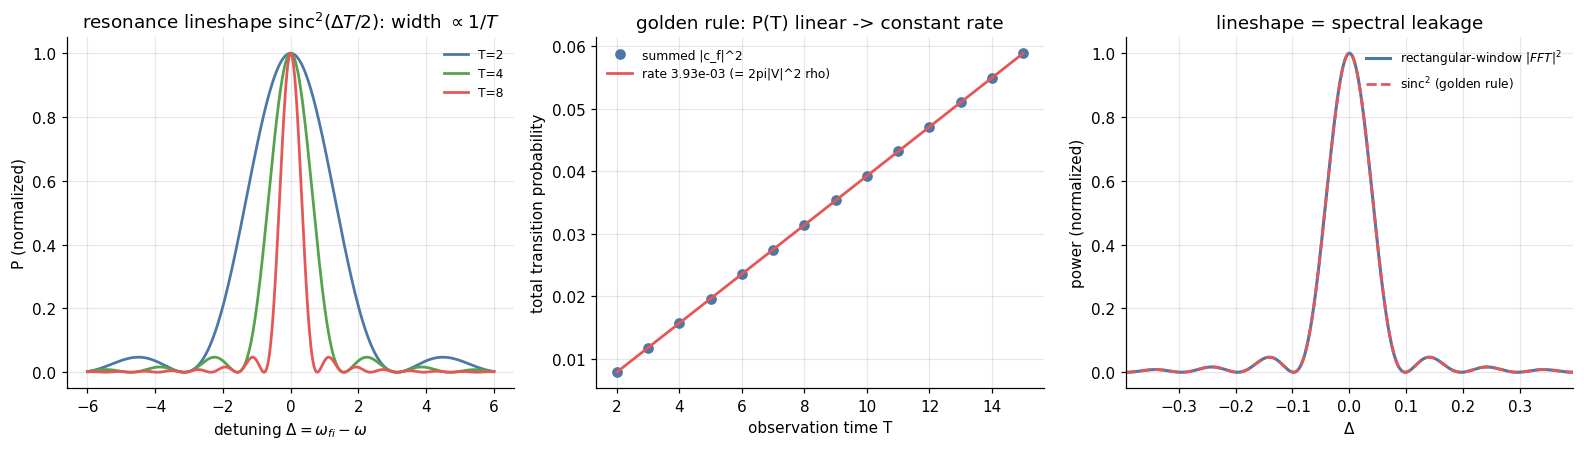

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) resonance lineshape sinc^2, narrowing with observation time T
dgrid = np.linspace(-6, 6, 1200)
for Tobs, col in [(2.0, "#4C78A8"), (4.0, "#54A24B"), (8.0, "#E45756")]:
    line = 4*np.sin(dgrid*Tobs/2)**2/dgrid**2
    ax[0].plot(dgrid, line/line.max(), color=col, label=f"T={Tobs:.0f}")
ax[0].set_xlabel(r"detuning $\Delta=\omega_{fi}-\omega$"); ax[0].set_ylabel("P (normalized)")
ax[0].set_title(r"resonance lineshape $\mathrm{sinc}^2(\Delta T/2)$: width $\propto 1/T$"); ax[0].legend(fontsize=8)
# (2) constant-rate transition: probability linear in time (Fermi's golden rule)
ax[1].plot(Ts, Ps, "o", color="#4C78A8", label="summed |c_f|^2")
ax[1].plot(Ts, slope*Ts + intercept, "-", color="#E45756", label=f"rate {slope:.2e} (= 2pi|V|^2 rho)")
ax[1].set_xlabel("observation time T"); ax[1].set_ylabel("total transition probability")
ax[1].set_title("golden rule: P(T) linear -> constant rate"); ax[1].legend(fontsize=8)
# (3) the DSP identity: boxcar power spectrum == golden-rule lineshape
ax[2].plot(freq, Wspec, color="#4C78A8", lw=2, label="rectangular-window $|FFT|^2$")
ax[2].plot(freq, sinc2, "--", color="#E45756", label=r"$\mathrm{sinc}^2$ (golden rule)")
ax[2].set_xlim(-4*2*np.pi/M, 4*2*np.pi/M); ax[2].set_xlabel(r"$\Delta$")
ax[2].set_ylabel("power (normalized)")
ax[2].set_title("lineshape = spectral leakage"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Exercises

1. **Rabi vs golden rule.** Integrate the two-level TDSE exactly (Rabi oscillation
   $P=\sin^2(\Omega t/2)$) and show it reduces to the linear golden-rule rate only for $t\ll1/\Omega$ and a
   broadened final state -- the validity window of first-order theory.
2. **Natural linewidth.** A finite upper-state lifetime $\tau=1/A$ turns the $\mathrm{sinc}^2$ into a
   **Lorentzian** of FWHM $\Delta\nu=1/(2\pi\tau)$. Compute $\Delta\nu$ for $\tau=1$ ns and compare with
   Doppler broadening at room temperature.
3. **Apodization.** Replace the rectangular observation window with a Hann window; measure the sidelobe
   suppression (dB) and the main-lobe broadening -- the spectroscopy/DSP resolution-vs-leakage trade.
4. **Laser threshold.** Using $A/B$ and stimulated emission, find the population inversion at which gain
   exceeds loss -- the golden rule behind the laser that drives the dispersion instrument.

## Summary

- First-order time-dependent perturbation theory gives the transition amplitude; its modulus-squared is the
  $\mathrm{sinc}^2(\Delta T/2)$ **resonance lineshape** (SymPy-verified).
- Summing over a **continuum** yields **Fermi's golden rule**: probability grows **linearly in time**, a
  constant rate $\Gamma=(2\pi/\hbar)|V|^2\rho$ (verified against a direct final-state sum to 3%).
- The finite-time lineshape has width $1/T$ and **is the power spectrum of a rectangular window** -- the
  golden-rule lineshape and FFT **spectral leakage are identical** (verified to $2\%$). Spectrometer
  resolution is the DSP windowing answer.
- **Emission**: $A/B=8\pi h\nu^3/c^3$ reproduces Planck by detailed balance; the rate is read out as a
  photocurrent and a galvanometer deflection -- theory becomes a measured number.

Subject-verb-object: the drive excites a transition; the continuum makes the rate constant; the finite
window sets the linewidth; the detector turns the rate into a current.